# Terceira Etapa
## 3. Análise Exploratória dos Dados (EDA): realize uma análise exploratória com foco em negócio, não só estatística. 
Responda: 
- Quais fatores parecem mais críticos para a satisfação? 
- O que mais gera detratores? 
- Existe algum “ponto de ruptura” na experiência do cliente? 
- Que tipo de cliente tende a ter NPS mais alto ou mais baixo? 

In [51]:
#!pip install pandas matplotlib numpy seaborn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

dataFrameBronze = pd.read_csv("../data/raw/desafio_nps_fase_1.csv")


### Renomeando as colunas

In [63]:
# Renomear todas as colunas para português
dataFrameBronze = dataFrameBronze.rename(columns={
    'customer_id': 'id_cliente',
    'customer_age': 'idade_cliente',
    'customer_region': 'regiao_cliente',
    'customer_tenure_months': 'tempo_cliente_meses',
    'order_id': 'id_pedido',
    'order_value': 'valor_pedido',
    'items_quantity': 'quantidade_itens',
    'discount_value': 'valor_desconto',
    'payment_installments': 'parcelamento',
    'delivery_time_days': 'dias_entrega',
    'delivery_delay_days': 'dias_atraso_entrega',
    'freight_value': 'valor_frete',
    'delivery_attempts': 'tentativas_entrega',
    'customer_service_contacts': 'contatos_atendimento',
    'resolution_time_days': 'dias_resolucao',
    'nps_score': 'score_nps',
    'repeat_purchase_30d': 'recompra_30d',
    'complaints_count': 'quantidade_reclamacoes',
    'csat_internal_score': 'score_csat_interno'
})

#dataFrameBronze.head()

### Verificando o DataSet

In [53]:
qualidade = pd.DataFrame({
    'tipo': dataFrameBronze.dtypes.astype(str),
    'nulos': dataFrameBronze.isna().sum(),
    '% nulos': (dataFrameBronze.isna().mean() * 100).round(2),
    'únicos': dataFrameBronze.nunique()
})
print(f'Linhas duplicadas: {dataFrameBronze.duplicated().sum()}')
print(f'NPS fora de 0–10: {((dataFrameBronze.score_nps < 0) | (dataFrameBronze.score_nps > 10)).sum()}')
display(qualidade)
#display(dataFrameBronze.describe(include='all').T)

Linhas duplicadas: 0
NPS fora de 0–10: 0


,tipo,nulos,% nulos,únicos
id_cliente,int64,0,0.0,2500
idade_cliente,int64,0,0.0,52
regiao_cliente,str,0,0.0,5
tempo_cliente_meses,int64,0,0.0,119
id_pedido,int64,0,0.0,2500
valor_pedido,float64,0,0.0,2457
quantidade_itens,int64,0,0.0,6
valor_desconto,float64,0,0.0,2050
parcelamento,int64,0,0.0,11
dias_entrega,int64,0,0.0,13


### Criando a Classificação

Nota média: 4.38 | Mediana: 4.40
NPS agregado da amostra: -80.0


,% clientes
categoria_nps,
Detrator (0–6),84.36
Passivo (7–8),11.24
Promotor (9–10),4.40


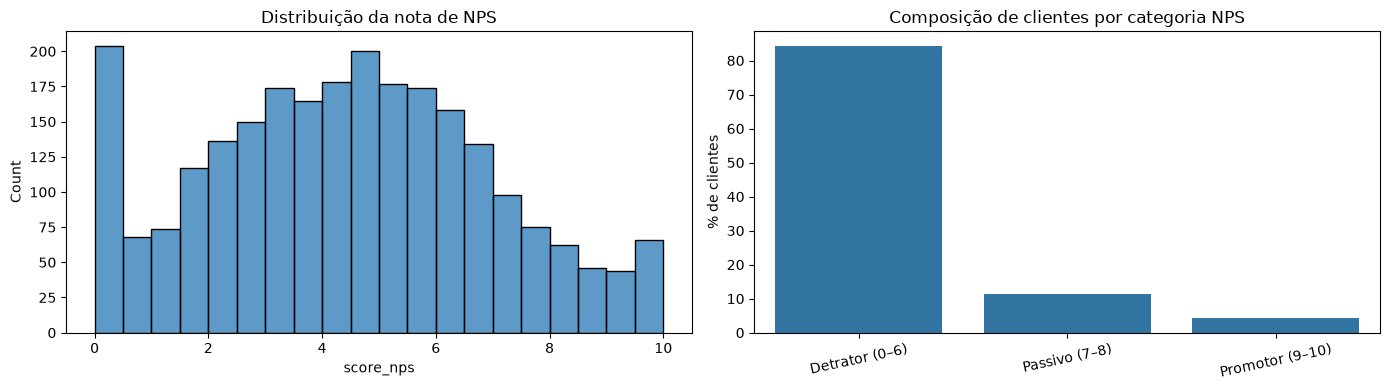

In [56]:

def classificar_nps(score):
    if score >= 9:
        return 'Promotor (9–10)'
    if score >= 7:
        return 'Passivo (7–8)'
    return 'Detrator (0–6)'


df_eda = dataFrameBronze.copy()
df_eda['categoria_nps'] = df_eda['score_nps'].apply(classificar_nps)
ordem_nps = ['Detrator (0–6)', 'Passivo (7–8)', 'Promotor (9–10)']
distribuicao = (df_eda['categoria_nps'].value_counts(normalize=True)
               .reindex(ordem_nps).mul(100).rename('% clientes'))
nps_agregado = distribuicao['Promotor (9–10)'] - distribuicao['Detrator (0–6)']
print(f'Nota média: {df_eda.score_nps.mean():.2f} | Mediana: {df_eda.score_nps.median():.2f}')
print(f'NPS agregado da amostra: {nps_agregado:.1f}')
display(distribuicao.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_eda, x='score_nps', bins=20, ax=axes[0], color='#2878B5')
axes[0].set_title('Distribuição da nota de NPS')
sns.barplot(x=distribuicao.index, y=distribuicao.values, ax=axes[1])
axes[1].set_title('Composição de clientes por categoria NPS')
axes[1].set_xlabel('')
axes[1].set_ylabel('% de clientes')
plt.xticks(rotation=12)
plt.tight_layout()

### Detalhando os detratores

In [66]:
dataFrameBronze.head()

,id_cliente,idade_cliente,regiao_cliente,tempo_cliente_meses,id_pedido,valor_pedido,quantidade_itens,valor_desconto,parcelamento,dias_entrega,dias_atraso_entrega,valor_frete,tentativas_entrega,contatos_atendimento,dias_resolucao,score_nps,recompra_30d,quantidade_reclamacoes,score_csat_interno
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [73]:
vwBronze = df_eda[
    [
    "idade_cliente",
    "tempo_cliente_meses",
    "valor_pedido",
    "valor_desconto",
    "dias_entrega",
    "dias_atraso_entrega",
    "valor_frete",
    "tentativas_entrega",
    "contatos_atendimento",
    "dias_resolucao",
    "score_nps",
    "recompra_30d",
    "quantidade_reclamacoes",
    "categoria_nps"
    ]]

vwDetratores = vwBronze[
    vwBronze["categoria_nps"] == "Detrator (0–6)"
]

vwPromotores = vwBronze[
    vwBronze["categoria_nps"] == "Promotor (9–10)"
]

vwPassivo = vwBronze[
    vwBronze["categoria_nps"] == "Passivo (7–8)"
]


vwContagemClassificacao = df_eda.groupby("categoria_nps").agg(
    qtdClassificacao = ("categoria_nps", "count")
)

print('Estatística dos Promotores')
display(vwPromotores.describe())

print('Estatística dos Detratores')
display(vwDetratores.describe())


Estatística dos Promotores


,idade_cliente,tempo_cliente_meses,valor_pedido,valor_desconto,dias_entrega,dias_atraso_entrega,valor_frete,tentativas_entrega,contatos_atendimento,dias_resolucao,score_nps,recompra_30d,quantidade_reclamacoes
count,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.0,110.000000
mean,43.627273,63.000000,468.084182,32.750364,7.936364,0.718182,37.050545,2.154545,0.672727,3.700000,9.606364,1.0,2.272727
std,15.455090,33.735887,281.021604,28.094782,3.819980,0.779694,12.614940,0.858699,0.836211,3.215644,0.371033,0.0,1.470874
min,18.000000,2.000000,64.870000,0.350000,2.000000,0.000000,4.080000,1.000000,0.000000,0.000000,9.000000,1.0,0.000000
25%,30.250000,34.250000,250.725000,7.852500,5.000000,0.000000,27.782500,1.000000,0.000000,1.000000,9.225000,1.0,1.000000
50%,43.500000,67.500000,402.675000,27.370000,8.000000,1.000000,36.255000,2.000000,0.000000,3.000000,9.600000,1.0,2.000000
75%,57.750000,90.000000,626.285000,51.240000,11.750000,1.000000,45.935000,3.000000,1.000000,6.000000,10.000000,1.0,3.000000
max,69.000000,119.000000,1372.620000,140.730000,14.000000,3.000000,69.430000,3.000000,4.000000,11.000000,10.000000,1.0,10.000000


Estatística dos Detratores


,idade_cliente,tempo_cliente_meses,valor_pedido,valor_desconto,dias_entrega,dias_atraso_entrega,valor_frete,tentativas_entrega,contatos_atendimento,dias_resolucao,score_nps,recompra_30d,quantidade_reclamacoes
count,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.0,2109.000000
mean,43.403035,61.433381,429.309540,29.442684,7.994310,2.414889,38.298326,1.997155,1.632053,5.694642,3.651778,0.0,4.442390
std,14.794920,34.594739,287.091872,29.043710,3.770449,1.426566,12.037688,0.809685,1.243670,3.440973,1.978905,0.0,1.675848
min,18.000000,1.000000,7.760000,0.020000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,31.000000,32.000000,216.050000,8.740000,5.000000,1.000000,29.930000,1.000000,1.000000,3.000000,2.200000,0.0,3.000000
50%,43.000000,62.000000,374.010000,20.460000,8.000000,2.000000,38.760000,2.000000,1.000000,6.000000,3.900000,0.0,4.000000
75%,56.000000,91.000000,572.300000,40.330000,11.000000,3.000000,46.360000,3.000000,2.000000,9.000000,5.300000,0.0,5.000000
max,69.000000,119.000000,1983.810000,230.330000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,6.900000,0.0,11.000000


In [59]:
df_eda['faixa_atraso'] = pd.cut(df_eda['dias_atraso_entrega'],
                                 bins=[-0.1, 0, 1, 3, np.inf],
                                 labels=['Sem atraso', '1 dia', '2–3 dias', '4+ dias'])
df_eda['faixa_contatos'] = pd.cut(df_eda['contatos_atendimento'],
                                   bins=[-0.1, 0, 1, 2, np.inf],
                                   labels=['0', '1', '2', '3+'])
df_eda['faixa_reclamacoes'] = pd.cut(df_eda['quantidade_reclamacoes'],
                                      bins=[-0.1, 0, 2, 4, np.inf],
                                      labels=['0', '1–2', '3–4', '5+'])

def resumo_segmento(coluna):
    return (df_eda.groupby(coluna, observed=True)
            .agg(clientes=('score_nps', 'size'), nps_medio=('score_nps', 'mean'),
                 pct_detratores=('categoria_nps', lambda x: (x == 'Detrator (0–6)').mean() * 100))
            .round(2))

for coluna in ['faixa_atraso', 'faixa_contatos', 'faixa_reclamacoes', 'regiao_cliente']:
    print(f'\n{coluna}')
    display(resumo_segmento(coluna))


faixa_atraso


,clientes,nps_medio,pct_detratores
faixa_atraso,,,
Sem atraso,277,6.86,51.62
1 dia,615,5.55,73.98
2–3 dias,1171,4.07,91.89
4+ dias,437,2.00,99.54



faixa_contatos


,clientes,nps_medio,pct_detratores
faixa_contatos,,,
0,554,5.54,70.76
1,816,4.66,83.95
2,640,4.12,88.59
3+,490,2.94,94.90



faixa_reclamacoes


,clientes,nps_medio,pct_detratores
faixa_reclamacoes,,,
0,23,8.52,17.39
1–2,399,6.58,54.64
3–4,1107,4.54,86.09
5+,971,3.20,96.19



regiao_cliente


,clientes,nps_medio,pct_detratores
regiao_cliente,,,
Centro-Oeste,468,4.21,84.19
Nordeste,485,4.42,85.57
Norte,506,4.38,85.18
Sudeste,520,4.37,83.65
Sul,521,4.49,83.30


### Problemas Encontrados
- A média de atraso nos detratores é mais que o triplo dos promotores.
- O tempo para resolução de problemas é muito maior 
- Consequentemente não tem recompra
- **Logistica ruim está impactando muito nos detratores**

### Verificando a Correlação

,correlação com NPS
dias_atraso_entrega,-0.597260
quantidade_reclamacoes,-0.496800
contatos_atendimento,-0.350845
dias_resolucao,-0.191392
valor_frete,-0.041087
idade_cliente,-0.009936
tempo_cliente_meses,-0.009711
dias_entrega,0.000925
quantidade_itens,0.011468
parcelamento,0.023718


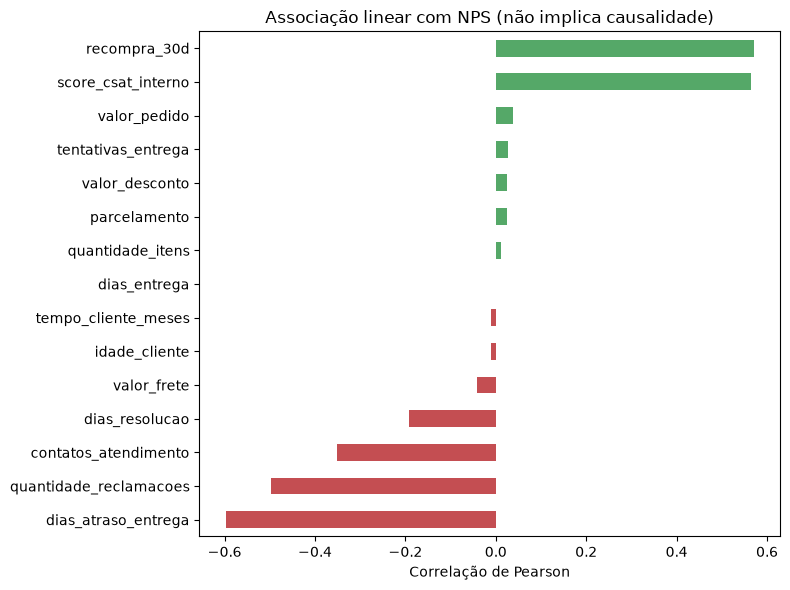

In [61]:
numericas_eda = df_eda.select_dtypes(include='number').columns.drop(['id_cliente', 'id_pedido'])
correlacoes = (df_eda[numericas_eda].corr(numeric_only=True)['score_nps']
               .drop('score_nps').sort_values())
display(correlacoes.to_frame('correlação com NPS'))

plt.figure(figsize=(8, 6))
correlacoes.sort_values().plot.barh(color=np.where(correlacoes.sort_values() < 0, '#C44E52', '#55A868'))
plt.title('Associação linear com NPS (não implica causalidade)')
plt.xlabel('Correlação de Pearson')
plt.tight_layout()